# DESCRIPTION OF THE PROBLEM
This analysis evaluates the company's sales performance, focusing on revenue concentration, customer behavior, and potential business risks. Based on this, the goal is to assess potential risks, such as dependence on specific markets or customers, as well as opportunities for improvement in customer retention and sales diversification. 
           
## 1. AVAILABLE DATA
The raw data was extracted from the following source:
https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx

- The dataset contains transactional sales information, including:
    - invoice number (InvoiceNo)
    - product code (StockCode)
    - product description (Description)
    - quantity of items sold (Quantity)
    - transaction date (InvoiceDate)
    - unit price of the product (UnitPrice)
    - customer identifier (CustomerID)
    - country of purchase (Country)
    - total transaction value (Sales)
- The dataset includes different types of records in the Description column, such as product names, operational charges (e.g., "AMAZONFEE", "Bank charges"), discounts, and generic entries (e.g., "amazon", "check", "counted").

In [30]:
# import required libraries for the analysis
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

## 2. Data Extraction (EXTRACT)

In [31]:
df = pd.read_excel("C:/Users/littl/OneDrive/Área de Trabalho/Dados/Portfolio/Loja/EN/Online Retail EN.xlsx")
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08


## 3. Data transformation (TRANSFORM)


### a) First, we check for missing values in the dataset.

In [32]:
# Displays the percentage of missing values in the column.
print((df.isnull().sum() / len(df))*100 ) 

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
Sales           0.000000
dtype: float64


- The 'Description' column contains 0.27% missing values. Since this proportion is low, these rows were removed.
- The 'CustomerID' column has 24.93% missing values (unidentified customers). Due to this high proportion, these records were retained to avoid a significant loss of data in the dataset.

In [33]:
# Deleting rows with empty 'Description' values
df.dropna(subset=['Description'], inplace=True)

### b) Next, the presence of cells with negative values is verified

In [34]:
# Shows the percentage of numerical columns that contain negative values
print((df.select_dtypes(include=['int64','float64']) < 0).sum() / len(df) * 100)

Quantity      1.806256
UnitPrice     0.000370
CustomerID    0.000000
Sales         1.718922
dtype: float64


In [35]:
# Analyzing the rows that contain negative values
df_neg = df[(df.select_dtypes(include='number') < 0).any(axis=1)]
df_neg.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom,-41.40
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-39.60
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom,-25.50


- Negative values are possibly associated with returns and operational charges. They can significantly impact revenue results, indicating the presence of losses that should be considered in this analysis.


### c) Analysis of null cells (values equal to zero)
- Records were identified with UnitPrice equal to zero, even with positive or negative quantities. These records do not represent actual financial transactions, indicating the presence of events not directly related to sales.

In [36]:
# Proportion of rows with UnitPrice equal to zero
print("Proportion of rows with UnitPrice equal to zero: ", (df['UnitPrice'] == 0).sum() / len(df) * 100)

# Sample of rows with UnitPrice equal to zero
df[df['UnitPrice'] == 0].head(10)

Proportion of rows with UnitPrice equal to zero:  0.19631606701760557


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
6391,536941,22734,amazon,20,2010-12-03 12:08:00,0.0,NaN,United Kingdom,0.0
6392,536942,22139,amazon,15,2010-12-03 12:08:00,0.0,NaN,United Kingdom,0.0
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.0,NaN,United Kingdom,0.0
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany,0.0
13217,537425,84968F,check,-20,2010-12-06 15:35:00,0.0,NaN,United Kingdom,0.0
13218,537426,84968E,check,-35,2010-12-06 15:36:00,0.0,NaN,United Kingdom,0.0
13264,537432,35833G,damages,-43,2010-12-06 16:10:00,0.0,NaN,United Kingdom,0.0
14335,537534,85064,CREAM SWEETHEART LETTER RACK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom,0.0
14336,537534,84832,ZINC WILLIE WINKIE CANDLE STICK,1,2010-12-07 11:48:00,0.0,NaN,United Kingdom,0.0
14337,537534,84692,BOX OF 24 COCKTAIL PARASOLS,2,2010-12-07 11:48:00,0.0,NaN,United Kingdom,0.0


- Since they are not related to revenue and represent a small proportion of the dataset, the rows with zero UnitPrice were removed.

In [37]:
df = df[df['UnitPrice'] != 0]

### d) Other unstandardized information
- There are also rows with generic 'Description' values that make it impossible to identify the type of transaction (whether it is a fee, discount, or sale).
- The 'Description' field presents different writing patterns, including records in uppercase, lowercase, and mixed formats. It is observed that products tend to be described predominantly in uppercase, while generic descriptions appear in lowercase. 
- After removing records with UnitPrice equal to zero, a new check were performed to identify any remaining generic descriptions.
- The removal of generic descriptions is necessary, as it is not possible to determine their nature, and they introduce uncertainty and compromise the quality of the analysis.

In [38]:
df[df['Description'].str.lower() == df['Description']]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales


- All rows with descriptions that do not allow identification of the nature of the transaction were removed. The dataset now contains only records with identifiable descriptions.

### e) Date standardization
- The 'InvoiceDate' column contains the year, month, day, and time of the transaction record. A new column called 'YearMonth' were created to display only the month and year, in order to facilitate data aggregation.

In [39]:
df['YearMonth'] = pd.to_datetime(df['InvoiceDate']).dt.to_period('M')
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


### f) Classifying the operations
- A column were created to indicate whether the record is a commercial product or not.

In [40]:
df.loc[
    (df['Quantity'] != 0) &
    (~df['Description'].fillna('').str.upper().str.contains(
        r'POSTAGE|DISCOUNT|VOUCHER|FEE|PACKING|COMMISSION|ADJUST|^CARRIAGE$|^NEXT DAY CARRIAGE$|^BANK ACCOUNT  GREETING  CARD$|^BANK CHARGES$', regex=True
    )),'IsProduct'] = True


### g) Detailed classification
- A new column were created for a more detailed classification of the products sold. This information is important to better segment sales data (SALE).

- Sales were categorized according to the nature of the products based on their descriptions (clothing, personal care, among others).
- The categorization was performed iteratively. Initially, the most frequent products were analyzed to identify patterns in the descriptions and define keywords for each category. These keywords were used in a classification function, categorize(), applied to the dataset. After each step, the items that were still unclassified were quantified and re-evaluated, allowing new terms to be included and the process to be refined until a satisfactory coverage (90% of the products) was achieved.

In [41]:
df['Category'] = None

def categorize(desc):
    desc = str(desc).upper()

    if any(p in desc for p in [
        'BAG','SHOPPER','LUNCH BOX','COAT','SILK FAN','WALLET','PARASOL','PURSE',
        'HAT','GLOVES','UMBRELLA','APRON','KEY FOB','BACKPACK'
    ]):
        return 'CLOTHING AND ACCESSORIES'

    elif any(p in desc for p in [
        'PLASTERS IN TIN','TISSUES','LIP GLOSS','BATH SPONGE','SEWING'
    ]):
        return 'PERSONAL CARE'

    elif any(p in desc for p in [
        'CAKESTAND','TINS','CASES','JAM MAKING','JARS','RECIPE BOX','TEACUP',
        'MOULDS','MOULD','NAPKINS','BOWLS','BOTTLE','BAKING SET','CUP',
        'KITCHEN SCALES','JUG CREAM','SPOONS','SHOPPING LIST','DRAWER KNOB',
        'CUTLERY','TIN','PANTRY','TEAPOT','MUG','GLASS','JAR','LID','DISPENSER',
        'WATERING CAN','MILK JUG','OVEN GLOVE','TEA CADDY','CLIPS','HERB MARKER',
        'RACK','SPADE','FOOT STOOL','GARDEN SECATEURS','HERB CONTAINER',
        'FRYING PAN','EGG FRYING PAN','SUGAR TONGS','TAPE MEASURE','BREAD BIN',
        'DRAWER CABINET','GARDENERS KNEELING','SNACK BOXES','TEA SET',
        'COOKIE CUTTERS','PEG','COOKIE CUTTER','PLATES','DOLLIES','STORAGE BOX',
        'BOWL','PLATE','TEA','COFFEE','SUGAR','FOOD CONTAINER','BOOK STAND',
        'WRAP','BIN','BUTTER DISH','BREAKFAST SET','DOILIES','BISCUIT CUTTERS',
        'TOADSTOOLS','SPOT BEAKER'
    ]):
        return 'KITCHEN AND HOUSEWARES'

    elif any(p in desc for p in [
        'HOLDER','BUNTING','ORNAMENT','CHALKBOARD','WICKER','PAPER CHAIN',
        'CHRISTMAS','FRAME','CLOCK','LANTERN','CANDLE','CANDLES','GARLAND',
        'DOORSTOP','MAGNETS','ADVENT CALENDAR','MIRROR','FLAGS','WALL ART',
        'TRELLIS','HOOK','PHOTO SHELF','PHOTO CUBE','METAL SIGN','SIGN',
        'HANGER','CUSHION','LADDER','ROPE','DOORMAT','TRINKET BOX','NIGHT LIGHT',
        'LIGHTS','BOARD','CAKE STAND','DECORATION','DECORATIONS','CHEST',
        'SLEIGH','HANGING','HOTTIE','CABINET','ROUNDERS','GARDEN SET','PEARS',
        'PLACEMATS','COASTERS','JEWELLERY BOX','BOOK BOX','DRAWER',
        'DRAWERKNOB','TRINKET','BUTTON BOX','MAT','WALL TIDY','DECORATIVE',
        'JINGLE BELL','TISSUE BOX'
    ]):
        return 'HOME DECOR'

    elif any(p in desc for p in [
        'KNITTING NANCY','SNAP CARDS','CARD GAME','SPACEBOY BIRTHDAY CARD',
        'SPINNING TOPS','TOY','TOYS','RIBBONS','BLOCK WORD','FELTCRAFT',
        'PLAYHOUSE','CRAYONS','MODELLING','CRAYON','PENCILS','COLOURING',
        'DOMINOES','NOTEBOOK','RULER','ROBOT','ALPHABET','PENCIL','ERASER',
        'GAME','CRAFT','STENCIL','NAUGHTS & CROSSES','MAGIC','GUMBALL',
        'BUBBLEGUM','SANDCASTLE','BALLOONS','BIB','HAND WARMER','HARMONICA',
        'SKITTLES','STATIONERY','MARSHMALLOWS','GIFT TAGS','PAINT SET','BINGO',
        'MONEY BANK','PIGGY BANK','PLAYING CARDS','CHALK STICKS','PEN','CARD',
        'NOTEPAD','STAMP','BIRTHDAY','NOTE BOOKS','RIBBON','TREASURE',
        'JIGSAW BLOCKS','PAINT YOUR OWN'
    ]):
        return 'TOYS AND GIFTS'

    return None

mask = df['IsProduct'].fillna(False)
df.loc[mask, 'Category'] = df.loc[mask, 'Description'].apply(categorize)

print(df.loc[mask, 'Category'].isna().mean() * 100)

# Most frequent examples of products still not classified
# print(df.loc[mask & df['Category'].isna(), 'Description'].value_counts().head(20))

df.loc[mask & df['Category'].isna(), 'Category'] = 'OTHER'

C:\Users\littl\AppData\Local\Temp\ipykernel_49924\3634654962.py:63: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = df['IsProduct'].fillna(False)


10.14855475941403


## 4. Analysis
### 4.1 Revenues
#### 4.1.1 Net revenue by month

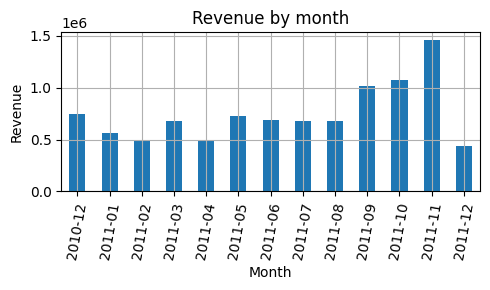

In [42]:
sales_time = df.groupby('YearMonth')['Sales'].sum()

# Plot
plt.figure(figsize=(5,3))
sales_time.plot(kind='bar')
plt.title('Revenue by month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=80)
plt.grid()
plt.tight_layout()
plt.show()

- The isolated monthly analysis does not allow for the identification of consistent behavioral patterns, as it is limited by the lack of historical data for comparison.


#### 4.1.2. Net revenue by country

In [43]:
sales_country = (
    df.groupby('Country')['Sales']
    .sum()
    .sort_values(ascending=False) )

total_sales = df['Sales'].sum()
# DataFrame with value and percent
sales_country_df = sales_country.to_frame(name='Sales')
sales_country_df['%'] = ((sales_country_df['Sales'] / total_sales)*100).round(2)

print("\n===== Revenue by country =====")
print(sales_country_df.head(5))


===== Revenue by country =====
                      Sales      %
Country                           
United Kingdom  8187806.364  84.00
Netherlands      284661.540   2.92
EIRE             263276.820   2.70
Germany          221698.210   2.27
France           197403.900   2.03


- Sales are highly concentrated in the United Kingdom, which alone accounts for approximately 85% of total revenue, while other countries have a very small and dispersed share, indicating a strong dependence on a single market. 

#### 4.1.3. Net revenue by customer


=== Net revenue of top 5 customers ===
                Sales  % of revenue
CustomerID                         
14646.0     279489.02          2.87
18102.0     256438.49          2.63
17450.0     187482.17          1.92
14911.0     132572.62          1.36
12415.0     123725.45          1.27


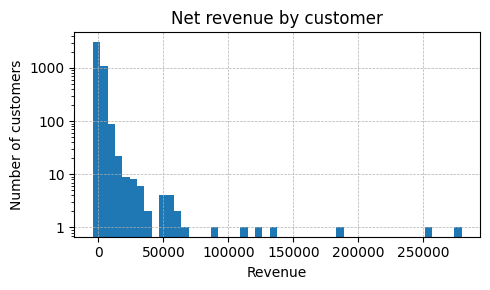

In [44]:
top_customers = ( df.groupby('CustomerID')['Sales'] .sum() .sort_values(ascending=False) .head(30)) 
top_customers_df = top_customers.to_frame(name='Sales')
top_customers_df['% of revenue'] = ((top_customers_df['Sales'] / total_sales)*100).round(2)
print("\n=== Net revenue of top 5 customers ===") 
print(top_customers_df.head(5)) 

sales_per_customer = df.groupby('CustomerID')['Sales'].sum() 
plt.figure(figsize=(5,3)) 
plt.hist(sales_per_customer, bins=50) 
plt.yscale('log') 
plt.gca().yaxis.set_major_locator(ticker.LogLocator(base=10)) 
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter()) 
plt.title('Net revenue by customer') 
plt.xlabel('Revenue') 
plt.ylabel('Number of customers') 
plt.grid(True, linestyle='--', linewidth=0.5) 
plt.tight_layout() 
plt.show()

- The data shows that only a few customers have a significant share of revenue, while the majority contribute minimally, indicating an uneven distribution and revenue concentration among specific customers.

#### 4.1.4. Top 10 products by net revenue


In [45]:
top_products = (
    df[(df['IsProduct']) & (df['Quantity'] > 0)]
    .groupby('Description')['Sales']
    .sum()
    .sort_values(ascending=False)
)

top_products_df = top_products.to_frame(name='Sales')

top_products_df['% of revenue'] = (
    top_products_df['Sales'] / total_sales * 100
).round(2)

print("\n=== Top 10 products by net revenue ===")
print(top_products_df.head(10))


=== Top 10 products by net revenue ===
                                        Sales  % of revenue
Description                                                
REGENCY CAKESTAND 3 TIER            174484.74          1.79
PAPER CRAFT , LITTLE BIRDIE         168469.60          1.73
WHITE HANGING HEART T-LIGHT HOLDER  106292.77          1.09
PARTY BUNTING                        99504.33          1.02
JUMBO BAG RED RETROSPOT              94340.05          0.97
MEDIUM CERAMIC TOP STORAGE JAR       81700.92          0.84
Manual                               78112.82          0.80
RABBIT NIGHT LIGHT                   66964.99          0.69
PAPER CHAIN KIT 50'S CHRISTMAS       64952.29          0.67
ASSORTED COLOUR BIRD ORNAMENT        59094.93          0.61


- Even the top 10 best-selling products represent only a limited share of total revenue, reinforcing the low concentration and diversification of sales.


### 4.2. Sales volume   
### 4.2.1. Top 10 products by volume

In [46]:
df_filtrado = df[
    (df['IsProduct']) &
    (df['Quantity'] > 0)]

top_products_quantity = (
    df_filtrado.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10))

print("\n=== Top products by volume ===")
print(top_products_quantity)


=== Top products by volume ===
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047
JUMBO BAG RED RETROSPOT               48474
WHITE HANGING HEART T-LIGHT HOLDER    37891
POPCORN HOLDER                        36761
ASSORTED COLOUR BIRD ORNAMENT         36461
PACK OF 72 RETROSPOT CAKE CASES       36419
RABBIT NIGHT LIGHT                    30788
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64


- It was observed that the products with the highest sales volume do not coincide with those generating the highest revenue.

- This indicates the presence of two distinct profiles:
    - high-volume, low unit-value products
    - lower-volume products with greater financial impact

- For performance analysis purposes, revenue was prioritized, as it directly reflects the economic impact of sales.

### 4.3. Customer analysis   
#### 4.3.1. Customer repurchase behavior


=== Customer distribution by purchase frequency ===
           Customers  % of total
InvoiceNo                       
1               1501       34.62
2-5             1968       45.39
6-10             531       12.25
11-20            242        5.58
21-50             79        1.82
51-100            12        0.28
100+               3        0.07


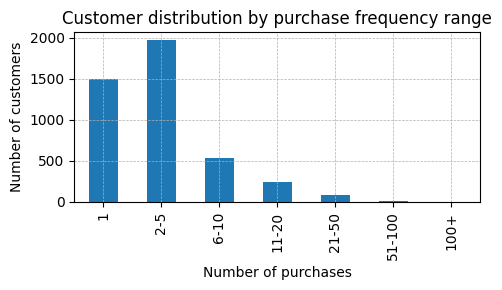

In [47]:
freq_customers = (
    df[
        (df['IsProduct']) &
        (df['Quantity'] > 0) &
        (df['CustomerID'].notna())]
    .groupby('CustomerID')['InvoiceNo']
    .nunique())  # List of customers with total completed purchases

# Faixas
bins = [0, 1, 5, 10, 20, 50, 100, float('inf')]
labels = ['1', '2-5', '6-10', '11-20', '21-50', '51-100', '100+']

freq_group = pd.cut(
    freq_customers,
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True)

# Counting
distribution = freq_group.value_counts().sort_index()

# Percent
distribution_pct = (distribution / distribution.sum() * 100).round(2)

# Join
distribution_df = pd.DataFrame({
    'Customers': distribution,
    '% of total': distribution_pct})

print("\n=== Customer distribution by purchase frequency ===")
print(distribution_df)

plt.figure(figsize=(5, 3))
distribution.plot(kind='bar')
plt.title('Customer distribution by purchase frequency range')
plt.xlabel('Number of purchases')
plt.ylabel('Number of customers')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

- Most customers make few purchases, with approximately 35% concentrated in a single order and 45% between 2 to 5 orders;
- In contrast, 20% of customers make more than 5 purchases, indicating the presence of a relevant group with high engagement and recurring behavior.   

#### 4.3.2. Revenue distribution among customers

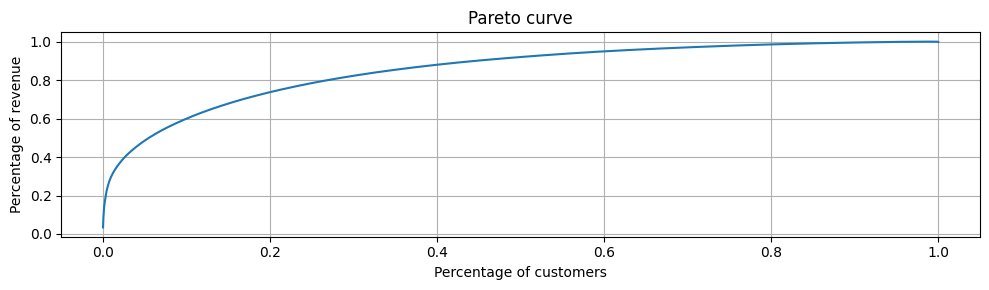

In [48]:
# Revenue by customer (sorted)
sales_per_customer = (
    df.groupby('CustomerID')['Sales']
    .sum()
    .sort_values(ascending=False))

# Cumulative percentage
cum_revenue = sales_per_customer.cumsum() / sales_per_customer.sum()
 # Percentage of customers
cum_clients = range(1, len(sales_per_customer) + 1)
cum_clients = [x / len(sales_per_customer) for x in cum_clients]

# Plot
plt.figure(figsize=(10,3))
plt.plot(cum_clients, cum_revenue)
plt.xlabel('Percentage of customers')
plt.ylabel('Percentage of revenue')
plt.title('Pareto curve')
plt.grid(True)
plt.tight_layout()
plt.show()

- The Pareto curve shows that approximately 30% of customers account for 80% of the revenue.


#### 4.3.3. Sales by customer recurrence

  Purchase frequency      Revenue  % of revenue
0                  1   618777.601          7.09
1                2-5  2340293.692         26.80
2               6-10  1489869.210         17.06
3              11-20  1670970.710         19.13
4              21-50  1428011.210         16.35
5             51-100   972696.870         11.14
6               100+   212995.610          2.44


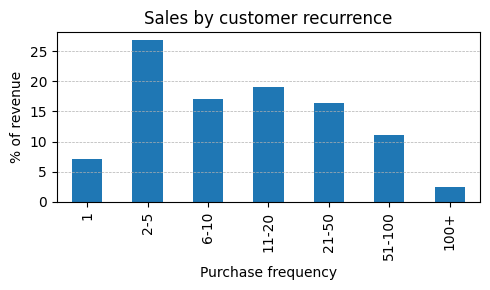

In [49]:
# Revenue from completed sales by customer
sales_per_customer = (
    df[
        (df['IsProduct']) &
        (df['Quantity'] > 0) &
        (df['CustomerID'].notna())
    ]
    .groupby('CustomerID')['Sales']
    .sum()
)

# Creating a table of purchase frequency and total sales
customer_df = pd.DataFrame({
    'freq': freq_customers,
    'revenue': sales_per_customer
}).dropna()

# Creating recurrence ranges
bins = [0, 1, 5, 10, 20, 50, 100, float('inf')]
labels = ['1', '2-5', '6-10', '11-20', '21-50', '51-100', '100+']

customer_df['range'] = pd.cut(
    customer_df['freq'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Revenue by rangea
sales_by_freq = customer_df.groupby('range', observed=False)['revenue'].sum()

# Percentual
sales_perc = (sales_by_freq / sales_by_freq.sum() * 100).round(2)

table = pd.DataFrame({
    'Purchase frequency': sales_by_freq.index,
    'Revenue': sales_by_freq.values,
    '% of revenue': sales_perc.values
})

print(table)

plt.figure(figsize=(5, 3))
sales_perc.plot(kind='bar')
plt.ylabel('% of revenue')
plt.xlabel('Purchase frequency')
plt.title('Sales by customer recurrence')
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

- The revenue concentration observed in the Pareto curve is directly related to repurchase behavior, as the higher recurrence ranges (2 to 20 purchases) account for 63% of the revenue; 
- This indicates that the main customers in the dataset are predominantly repeat customers.   

#### 4.3.4. Signs of customer inactivity
A metric based on the interval between purchases was explored to identify potential signs of customer inactivity. However, this analysis depends on a complete transaction history and additional context, and is not suitable for standalone interpretation. 

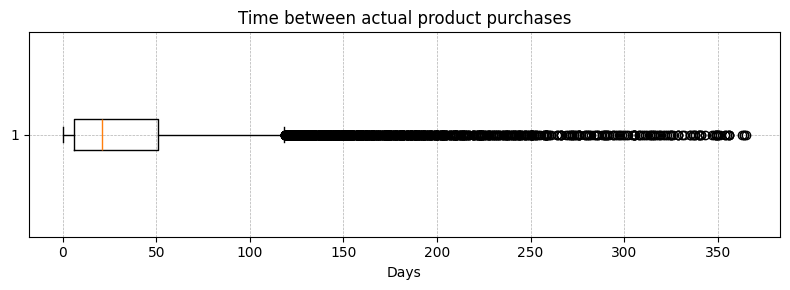

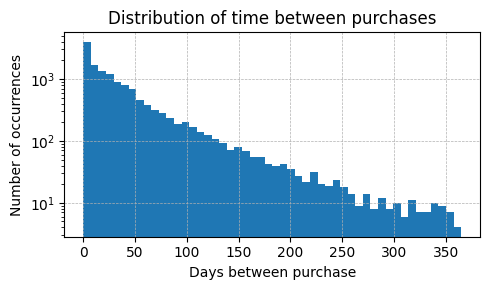

In [50]:
# Ensure date format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Filter only actual product purchases
df_valid = df[
    (df['IsProduct']) &
    (df['Quantity'] > 0) &
    (df['CustomerID'].notna())
].copy()

# Keep only one row per invoice
purchases = (
    df_valid[['CustomerID', 'InvoiceNo', 'InvoiceDate']]
    .dropna(subset=['CustomerID', 'InvoiceNo', 'InvoiceDate'])
    .drop_duplicates(subset=['CustomerID', 'InvoiceNo'])
    .sort_values(['CustomerID', 'InvoiceDate'])
    .copy()
)

# Previous purchase date by customer
purchases['prev_date'] = purchases.groupby('CustomerID')['InvoiceDate'].shift(1)

# Time between purchases (in days)
purchases['days_between'] = (
    purchases['InvoiceDate'] - purchases['prev_date']
).dt.days

# Remove first purchase (no prior history)
repurchase = purchases.dropna(subset=['days_between']).copy()

# Boxplot
plt.figure(figsize=(8, 3))
plt.boxplot(repurchase['days_between'], vert=False)
plt.title('Time between actual product purchases')
plt.xlabel('Days')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Histogram (log scale))
plt.figure(figsize=(5, 3))
plt.hist(repurchase['days_between'], bins=50)
plt.yscale('log')
plt.title('Distribution of time between purchases')
plt.xlabel('Days between purchase')
plt.ylabel('Number of occurrences')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

- It was observed that repurchase behavior shows high variability among customers, making it unfeasible to use a single mean or median value as a general reference.
- There are approximately 4000 repurchase occurrences with a 10-day interval, with a progressive decrease as the interval increases, reaching few occurrences at longer intervals (for example, around 10 occurrences with a 300-day interval).

#### 4.3.5. Customer repurchase profile


=== Customer repurchase profile ===
CustomerProfile
ONE-TIME         1537
UP TO 7 DAYS      189
8–30 DAYS         745
31–90 DAYS       1211
91–180 DAYS       481
OVER 180 DAYS     209
Name: count, dtype: int64


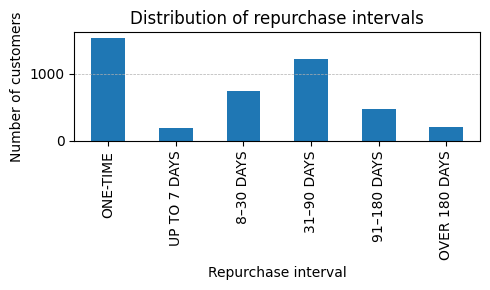

In [51]:
# Median time between purchases
avg_days = (
    repurchase
    .groupby('CustomerID')['days_between']
    .median())

# Classification function
def classify_customer(days):
    if pd.isna(days):
        return 'ONE-TIME'
    elif days <= 7:
        return 'UP TO 7 DAYS'
    elif days <= 30:
        return '8–30 DAYS'
    elif days <= 90:
        return '31–90 DAYS'
    elif days <= 180:
        return '91–180 DAYS'
    else:
        return 'OVER 180 DAYS'

customer_profile = avg_days.apply(classify_customer)

# Add to the original DataFrame
df['CustomerProfile'] = df['CustomerID'].map(customer_profile)

# Customers with only one purchase
df['CustomerProfile'] = df['CustomerProfile'].fillna('ONE-TIME')

profile_dist = (
    df[['CustomerID', 'CustomerProfile']]
    .drop_duplicates()
    ['CustomerProfile']
    .value_counts())

order = [
    'ONE-TIME',
    'UP TO 7 DAYS',
    '8–30 DAYS',
    '31–90 DAYS',
    '91–180 DAYS',
    'OVER 180 DAYS']

profile_dist = profile_dist.reindex(order)

print("\n=== Customer repurchase profile ===")
print(profile_dist)

plt.figure(figsize=(5, 3))
profile_dist.plot(kind='bar')
plt.title('Distribution of repurchase intervals')
plt.xlabel('Repurchase interval')
plt.ylabel('Number of customers')
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

- Most repeat customers make purchases at intervals of 2 to 3 months. There is also a relevant share of customers with shorter repurchase intervals (up to 30 days), as well as others with intervals between 4 and 6 months.
- Customers with intervals longer than 180 days show low repurchase frequency, indicating less regular behavior over the analyzed period.

#### 4.3.6. Customer classification by net revenue and number of repeat purchases


=== Top customers: revenue vs frequency ===
              revenue  frequency
CustomerID                      
14646.0     279489.02         72
18102.0     256438.49         60
17450.0     187482.17         46
14911.0     132572.62        200
12415.0     123725.45         20
14156.0     113384.14         54
17511.0      88125.38         31
16684.0      65892.08         28
13694.0      62653.10         50
15311.0      59419.34         91


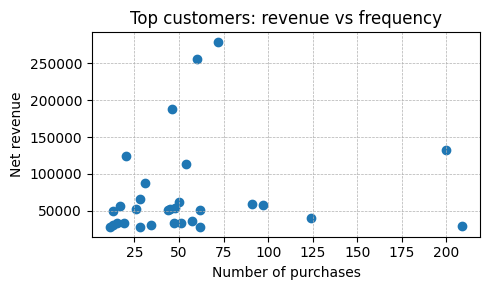

In [52]:
# Combine the information
top_analysis = pd.DataFrame({
    'revenue': top_customers,
    'frequency': freq_customers
})

# Remove possible NaN values
top_analysis = top_analysis.dropna()
top_analysis = top_analysis.sort_values(by='revenue', ascending=False)

print("\n=== Top customers: revenue vs frequency ===")
print(top_analysis.head(10))

plt.figure(figsize=(5,3))

plt.scatter(top_analysis['frequency'], top_analysis['revenue'])

plt.xlabel('Number of purchases')
plt.ylabel('Net revenue')

plt.title('Top customers: revenue vs frequency')

plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

- The occurrences are concentrated in a quadrant with a lower number of repurchases and lower net revenue. 
- Still, there are notable revenue values associated with customers with more than 25 repurchases, indicating a consistent level of loyalty among high-value customers.

### 4.4 Returns
#### 4.4.1 Return rate by product category

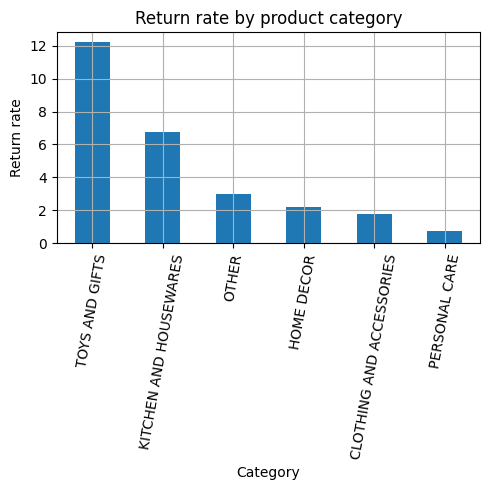

In [53]:
sales = (
    df[(df['IsProduct']) & (df['Quantity'] > 0)]
    .groupby('Category')['Quantity']
    .sum())

refunds = (
    df[(df['IsProduct']) & (df['Quantity'] < 0)]
    .groupby('Category')['Quantity']
    .sum()
    .abs())

return_rate = (refunds / sales).sort_values(ascending=False)*100

plt.figure(figsize=(5, 5))
return_rate.plot(kind='bar')
plt.title('Return rate by product category')
plt.ylabel('Return rate')
plt.xticks(rotation=80)
plt.grid()
plt.tight_layout()
plt.show()

- The Toys and Gifts category has the highest return rate, followed by Kitchen and Housewares items, at approximately 7%.

#### 4.4.2 Total return volume by customer

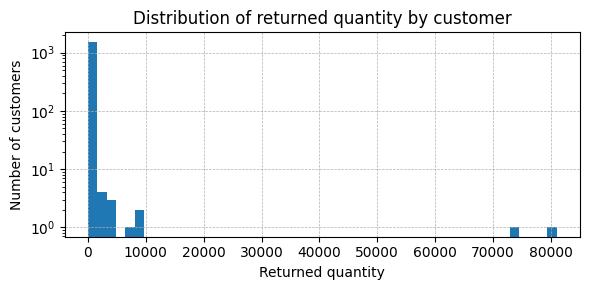

In [54]:
refunds_per_customer = (
    df[(df['IsProduct']) & (df['Quantity'] < 0)]
    .groupby('CustomerID')['Quantity']
    .sum()
    .abs())

analysis = pd.DataFrame({
    'Purchase': freq_customers,
    'Spending': sales_per_customer,
    'Return': refunds_per_customer
}).fillna(0)

plt.figure(figsize=(6, 3))
plt.hist(refunds_per_customer.dropna(), bins=50)

plt.title('Distribution of returned quantity by customer')
plt.xlabel('Returned quantity')
plt.ylabel('Number of customers')
plt.yscale('log')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

- Large-volume, isolated returns were identified, which may indicate order cancellations at scale, possibly related to wholesale transactions.

#### 4.4.3. Impact of returns and adjustments on revenue

In [55]:
net_revenue = df['Sales'].sum()
negative_revenue = df[df['Sales'] < 0]['Sales'].sum()
percentual_impact = abs(negative_revenue) / net_revenue * 100

print(f"Total net revenue: {net_revenue:.2f}")
print(f"Total of negative operations: {negative_revenue:.2f}")
print(f"Impact on revenue: {percentual_impact:.2f}%")

Total net revenue: 9747747.93
Total of negative operations: -918936.61
Impact on revenue: 9.43%


- The analysis showed that records related to returns, discounts, and operational fees from platforms and banks account for approximately 9.43% of net revenue, indicating that a relevant portion of the revenue was reduced by these types of operations over the analyzed period.

## 5. Data export (LOAD)

In [56]:
df.to_csv('C:/Users/littl/OneDrive/Área de Trabalho/Dados/Portfolio/Loja/EN/Cleaned_data_EN.csv')

## 6. Business analysis

- Approximately 85% of revenue is concentrated in the United Kingdom, indicating a strong dependence on this market. This concentration increases the business’s exposure to risks associated with local economic and operational factors.

- It was observed that the top five customers account for approximately 10% of total revenue. This indicates a relatively balanced distribution of revenue across customers. Such a scenario may positively impact business stability by reducing dependence on individual customers and making revenue less sensitive to the loss of specific consumers.

- The top 10 products represent a limited share of total revenue, indicating low concentration and greater diversification of sales. Additionally, it was observed that the highest-volume products are not the ones generating the most revenue, highlighting the coexistence of high-turnover, low unit-value items and lower-volume products with higher financial impact. This may influence pricing strategies and product prioritization, directing focus toward items with higher financial contribution.

- It was observed that most customers make few purchases, with around 80% of customers concentrated between 1 and 5 orders, while a smaller portion exhibits recurring behavior. Still, approximately 30% of customers are responsible for 80% of revenue, as indicated by the Pareto curve. This suggests that revenue is strongly associated with repeat and loyal customers, as higher purchase frequency groups account for most of the revenue, highlighting their importance to business performance.

- Repurchase behavior shows high variability among customers, with a higher concentration of occurrences at short intervals (around 10 days) and medium intervals (between 2 and 3 months). This indicates the presence of a consistent group of engaged customers contributing to business recurrence, while longer intervals are associated with less regular behavior. This can positively impact demand predictability and support the development of targeted strategies for customer retention and reactivation.

- The Toys and Gifts category shows the highest return rate, followed by kitchen and home decor items, along with isolated cases of large-volume returns. This may indicate mismatches between products and customer expectations or specific large-scale order cancellations. Such factors can negatively impact operational and logistics costs, as well as reduce margins and sales efficiency in these categories.

- Negative transactions correspond to returns or adjustments that directly impact the company’s final revenue. An impact of 9.43% indicates that a significant portion of the generated revenue is not effectively converted into net results. From a business perspective, understanding this impact is essential to evaluate operational efficiency and identify improvement opportunities, such as reducing returns, reviewing logistics processes, and improving sales quality. Monitoring this metric directly contributes to revenue preservation and the improvement of operating margins.